# Hyperparameter - Trajectory Relationship
This simulation is intended to demonstrate the impacts of environmental hyperparameters on the ergodic trajectories generated.

In [1]:
import Pkg; Pkg.activate(""); Pkg.instantiate()

  Activating project at `~/Kaleb_Data/PhD_Research/CPS_Project/adaptive-ocean-exploration-sim`


In [2]:
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

In [3]:
using Plots, Revise, StaticArrays, Interpolations, LinearAlgebra

In [4]:
include("src/kf.jl")
include("src/ngpkf.jl")
include("src/SyntheticData.jl")
include("src/ergodic.jl")
include("src/simulator_spatial.jl")

Main.SimulatorSpatial

## Spatial-only Matern-12 Kernel

In [5]:
# Define domain vars
dim = 100; # number of data points along each axis in the domain (defining a square domain)
xstart, xstop = 0, 25; # x-axis start and end positions
ystart, ystop = 0, 10; # y-axis start and end positions

σ_sq = 1.0
λₓ = 1/(4.0) 

env_data = SyntheticData.matern12_spatial(dim, xstart, xstop, ystart, ystop, σ_sq, λₓ);
# heatmap(range(xstart, stop=xstop, length=dim), range(ystart, stop=ystop, length=dim), env_data; c = :vik)
# title!("Synthetic Data: σ² = $(σ_sq), λₓ = $(λₓ)")

In [6]:
plotly();
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
plot!(clims=(-2,2))

┌ Warning: Failed to load integration with PlotlyBase & PlotlyKaleido.
│   exception =
│    ArgumentError: Package PlotlyBase not found in current path.
│    - Run `import Pkg; Pkg.add("PlotlyBase")` to install the PlotlyBase package.
│    Stacktrace:
│      [1] macro expansion
│        @ Base ./loading.jl:1766 [inlined]
│      [2] macro expansion
│        @ Base ./lock.jl:267 [inlined]
│      [3] __require(into::Module, mod::Symbol)
│        @ Base ./loading.jl:1747
│      [4] #invoke_in_world#3
│        @ Base ./essentials.jl:921 [inlined]
│      [5] invoke_in_world
│        @ Base ./essentials.jl:918 [inlined]
│      [6] require(into::Module, mod::Symbol)
│        @ Base ./loading.jl:1740
│      [7] top-level scope
│        @ ~/.julia/packages/Plots/ju9dp/src/backends.jl:565
│      [8] eval
│        @ ./boot.jl:385 [inlined]
│      [9] _initialize_backend(pkg::Plots.PlotlyBackend)
│        @ Plots ~/.julia/packages/Plots/ju9dp/src/backends.jl:564
│     [10] backend
│        @ Plots 

In [234]:
# Create an ngpkf grid based on the data
λₓ_wrong = 1/(2.5) 

σ_spatial = σ_sq
l_spatial = 1/λₓ_wrong
# l_spatial = 1/λₓ

res_factor = 0.4 #l_spatial / sqrt(2.0)

kern = NGPKF.MaternKernel(σ_spatial, l_spatial)

ngp_grid_x = range(extrema(env_data.X)..., step= res_factor )
ngp_grid_y = range(extrema(env_data.Y)..., step= res_factor )



# ngp_grid_x = range(extrema(env_data.X)..., length=10) # step= res_factor )
# ngp_grid_y = range(extrema(env_data.Y)..., length=10)# step= res_factor )

0.0:0.4:10.0

In [235]:
ngpkf_grid = NGPKF.NGPKFGrid(ngp_grid_x, ngp_grid_y, kern)

Main.NGPKF.NGPKFGrid{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{SVector{2, Float64}}, Hermitian{Float64, Matrix{Float64}}, Main.NGPKF.MaternKernel{Float64}}(0.0:0.4:24.8, 0.0:0.4:10.0, SVector{2, Float64}[[0.0, 0.0], [0.4, 0.0], [0.8, 0.0], [1.2, 0.0], [1.6, 0.0], [2.0, 0.0], [2.4, 0.0], [2.8, 0.0], [3.2, 0.0], [3.6, 0.0]  …  [21.2, 10.0], [21.6, 10.0], [22.0, 10.0], [22.4, 10.0], [22.8, 10.0], [23.2, 10.0], [23.6, 10.0], [24.0, 10.0], [24.4, 10.0], [24.8, 10.0]], Main.NGPKF.MaternKernel{Float64}(1.0, 2.5), [5.27312445875815 -2.6598615606878075 … 1.231159606777094e-9 3.0351648911604957e-9; -2.6598615606878075 7.082624429830062 … 4.2905915806919005e-10 1.2311596060399628e-9; … ; 1.231159606777094e-9 4.2905915806919005e-10 … 7.082624429830041 -2.6598615606877862; 3.0351648911604957e-9 1.2311596060399628e-9 … -2.6598615606877862 5.273124458758133])

In [236]:
size(ngp_grid_x), size(ngp_grid_y)

((63,), (26,))

In [237]:
@assert maximum(abs.(ngpkf_grid.invK)) < 10.0


In [238]:
maximum(abs.(ngpkf_grid.invK))


8.141577135375561

In [239]:
size(ngpkf_grid.invK')


(1638, 1638)

In [240]:
x0s = [@SVector[rand(ngpkf_grid.xs[2:(end-2)]), rand(ngpkf_grid.ys[2:(end-2)])] for i=1:1]


1-element Vector{SVector{2, Float64}}:
 [4.8, 3.6]

In [241]:
SimulatorSpatial.measure(0.0, x0s, env_data; σ_meas = 0.05)

1-element Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}:
 Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}(0.0, [4.8, 3.6], 0.6774548517112926)

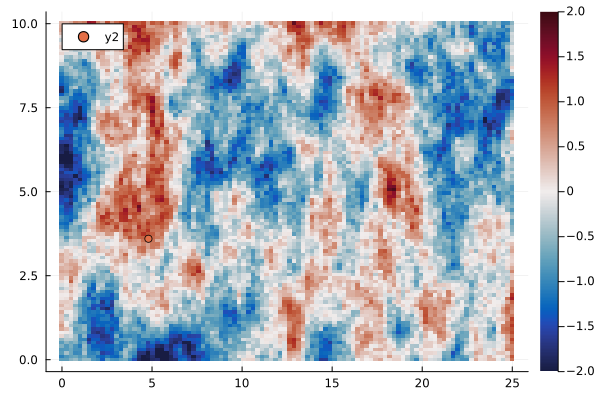

In [242]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
scatter!(first.(x0s), last.(x0s))
plot!(clims=(-2,2))

In [243]:
ΔT = 5.0 / 60.0 # seconds
Tend = 1.0 # hours 
ts = 0.0:(ΔT):(Tend * 60)

0.0:0.08333333333333333:60.0

In [244]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(ΔT)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

DxS (generic function with 1 method)

In [245]:
using DifferentialEquations
using ForwardDiff

function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end

C = 1.0
R = 0.5
Q = 0.0
Clarity_decay(u,p,t) = (C^2 / R) * (1-u)^2 - Q * u^2


function Forward_Simulate_Clarity(current_clarity, target_clarity; fn::Function = Clarity)
    """
    Forward simulate for maximum 10 seconds
    Here for now I only consider the spatiostatic environment 
    """    
    tspan = (0.0, 10.0) # 10 is just chosen to be a huge value for this problem
    u0 = current_clarity
    prob = ODEProblem(fn, u0, tspan)
    condition(u, t, integrator) = u ≥ target_clarity
    affect!(integrator) = terminate!(integrator)
    cb = DiscreteCallback(condition, affect!)
    sol = solve(prob, Tsit5(), callback = cb);
    return sol.t[end]
    
end

Forward_Simulate_Clarity (generic function with 1 method)

In [246]:
# Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

In [247]:
 δt = Forward_Simulate_Clarity(0.5, 0.9; fn = Clarity_decay)

4.941428437228555

In [248]:
using LinearAlgebra, StatsBase

function ergo_controller3(t, xs; 
        ergo_grid,
        ergo_q_map,
        traj,
        umax=30.0 * 60 / 1000,
        ΔT,
        kwargs...
        )

    target_q = 0.8 ; # * ones(size(ergo_q_map))

    target_spatial_dist = zeros(size(ergo_q_map))

    Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

    C_ = Cfun(0,0)
    R_ = Rfun(0,0)
    
#     println("ergo_q_map: $(ergo_q_map)")
    
    for i in CartesianIndices(target_spatial_dist)
        if target_q > ergo_q_map[i]
            target_spatial_dist[i] = Forward_Simulate_Clarity(ergo_q_map[i], target_q; fn = Clarity_decay)
        else
            target_spatial_dist[i] = 0.0
        end
#         target_spatial_dist[i] = clarity_time(ergo_q_map[i], target_q, C_, R_, Qp)
        

    end
    
#     println("target_spatial_dist: $(target_spatial_dist)")
    # Remove Nans
    
#     for cell in CartesianIndices(target_spatial_dist)
#         if isnan(target_spatial_dist[cell])
#             target_spatial_dist[cell] = 0
#         else 
#             target_spatial_dist[cell] = max(0, target_spatial_dist[cell])
#         end
#     end
        
    u = [ErgodicController.controller_single_integrator(ergo_grid, x, traj, target_spatial_dist; umax=umax) for x in xs]
    return u

end

ergo_controllers3 = [ergo_controller3 for i=1:length(x0s)]

1-element Vector{typeof(ergo_controller3)}:
 ergo_controller3 (generic function with 1 method)

In [249]:
ΔT = 5.0/60.0 # minutes
Tend = 0.1 # hours 
ts = 0.0:(ΔT):(90)
fuse_measurements_every_ΔT = 5.0 # minutes
recompute_controller_every_ΔT = 5.0 / 60.0 # minutes
σ_t = zeros(63, 26);

In [250]:
5.0/60.0

0.08333333333333333

In [251]:
@time res_ergo =  SimulatorSpatial.simulate_spatial(ts, x0s, ergo_controller3; 
    ngpkf_grid=ngpkf_grid, 
    EnvDataSpatial=env_data, 
    σ_meas = 0.5,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)

Progress:   0%|                                         |  ETA: N/A
Progress:   1%|▎                                        |  ETA: 0:21:37
Progress:   1%|▌                                        |  ETA: 0:21:12
Progress:   2%|▋                                        |  ETA: 0:20:49
Progress:   2%|▉                                        |  ETA: 0:20:38
Progress:   3%|█▏                                       |  ETA: 0:20:31
Progress:   3%|█▍                                       |  ETA: 0:20:22
Progress:   4%|█▋                                       |  ETA: 0:20:15
Progress:   4%|█▉                                       |  ETA: 0:20:05
Progress:   5%|██                                       |  ETA: 0:19:57


Inside prediction of NGP


Progress:   6%|██▎                                      |  ETA: 0:19:48
Progress:   6%|██▌                                      |  ETA: 0:19:44
Progress:   7%|██▊                                      |  ETA: 0:19:30
Progress:   7%|███                                      |  ETA: 0:19:16
Progress:   8%|███▎                                     |  ETA: 0:19:02
Progress:   8%|███▍                                     |  ETA: 0:18:49
Progress:   9%|███▋                                     |  ETA: 0:18:37
Progress:   9%|███▉                                     |  ETA: 0:18:26
Progress:  10%|████▏                                    |  ETA: 0:18:19
Progress:  11%|████▍                                    |  ETA: 0:18:09


Inside prediction of NGP


Progress:  11%|████▌                                    |  ETA: 0:17:59
Progress:  12%|████▊                                    |  ETA: 0:17:52
Progress:  12%|█████                                    |  ETA: 0:17:42
Progress:  13%|█████▎                                   |  ETA: 0:17:31
Progress:  13%|█████▌                                   |  ETA: 0:17:20
Progress:  14%|█████▊                                   |  ETA: 0:17:09
Progress:  14%|█████▉                                   |  ETA: 0:16:58
Progress:  15%|██████▏                                  |  ETA: 0:16:48
Progress:  16%|██████▍                                  |  ETA: 0:16:38
Progress:  16%|██████▋                                  |  ETA: 0:16:28


...

Inside prediction of NGP


Progress:  94%|██████████████████████████████████████▊  |  ETA: 0:00:45
Progress:  95%|███████████████████████████████████████  |  ETA: 0:00:40
Progress:  96%|███████████████████████████████████████▏ |  ETA: 0:00:36
Progress:  96%|███████████████████████████████████████▍ |  ETA: 0:00:31
Progress:  97%|███████████████████████████████████████▋ |  ETA: 0:00:27
Progress:  97%|███████████████████████████████████████▉ |  ETA: 0:00:22
Progress:  98%|████████████████████████████████████████▏|  ETA: 0:00:18
Progress:  98%|████████████████████████████████████████▍|  ETA: 0:00:13
Progress:  99%|████████████████████████████████████████▌|  ETA: 0:00:09
Progress:  99%|████████████████████████████████████████▊|  ETA: 0:00:04


790.966423 seconds (29.89 G allocations: 692.418 GiB, 6.48% gc time, 0.03% compilation time: 72% of which was recompilation)


Progress: 100%|█████████████████████████████████████████| Time: 0:13:09
Progress: 100%|█████████████████████████████████████████| Time: 0:13:09


Main.SimulatorSpatial.SimResult{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{SVector{2, Float64}}}, Vector{Vector{SVector{2, Float64}}}, Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}, Vector{Float64}, Vector{Main.KF.KFState{Vector{Float64}, UpperTriangular{Float64, Matrix{Float64}}}}, Vector{Matrix{Float64}}}(0.0:0.08333333333333333:90.0, Vector{SVector{2, Float64}}[[[4.8, 3.6]], [[4.869698520426403, 3.732823628358701]], [[4.94475097171188, 3.862697142040441]], [[5.04276439679012, 3.9762461116721917]], [[5.145742753715134, 4.085312412631857]], [[5.2533237607213366, 4.189841484815299]], [[5.340865075728019, 4.311646731692848]], [[5.434195992427236, 4.429074752148291]], [[5.527665984186228, 4.546392102274238]], [[5.621001642637184, 4.663816353864472]]  …  [[24.126056178867234, 0.9608136103597934]], [[24.182218163961632, 1.0824981261265927]], [[24.233699983631496, 1.2115913440642492]], [[2

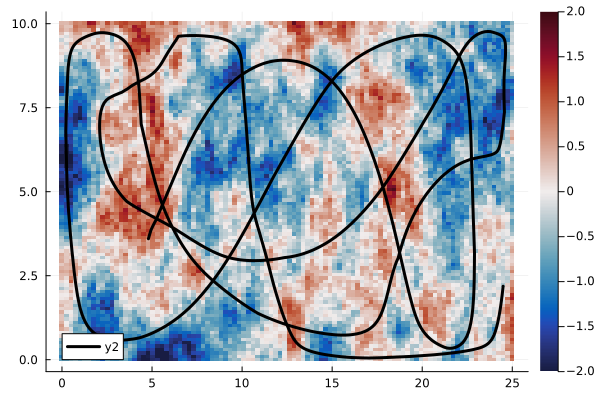

In [252]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
for i=1:length(x0s)
    x = [r[i][1] for r in res_ergo.xs]
    y = [r[i][2] for r in res_ergo.xs]
    plot!(x, y, linewidth=3, color=:black)
end
plot!()

┌ Info: Saved animation to
└ /home/dasc-group/KalebData/PhDResearch/CPS_Project/adaptive-ocean-exploration-sim/tmp.gif


Plots.AnimatedGif("/home/dasc-group/Kaleb_Data/PhD_Research/CPS_Project/adaptive-ocean-exploration-sim/tmp.gif")
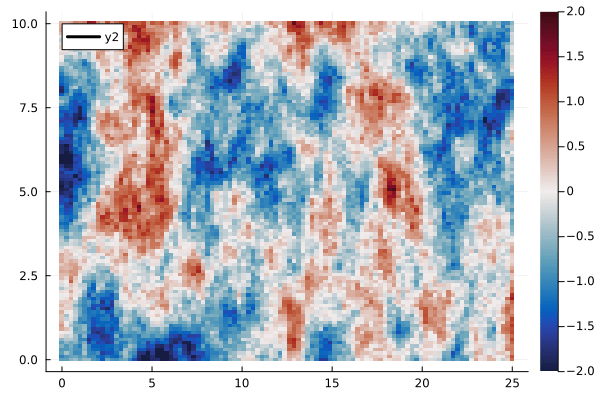

In [253]:
gr()
@gif for n = Int.(floor.(range(1, length(res_ergo.xs), length=420)))
    plot()
    heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
    for i=1:length(x0s)
        x = [r[i][1] for r in res_ergo.xs[1:n]]
        y = [r[i][2] for r in res_ergo.xs[1:n]]
        plot!(x, y, linewidth=3, color=:black)
    end
    plot!()
end

In [254]:
size(res_ergo.w_hats)

(18,)

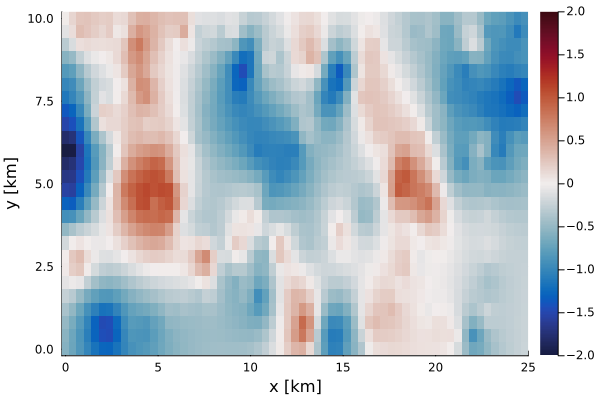

attempt to save state beyond implementation limit


In [255]:
gr()

p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2))


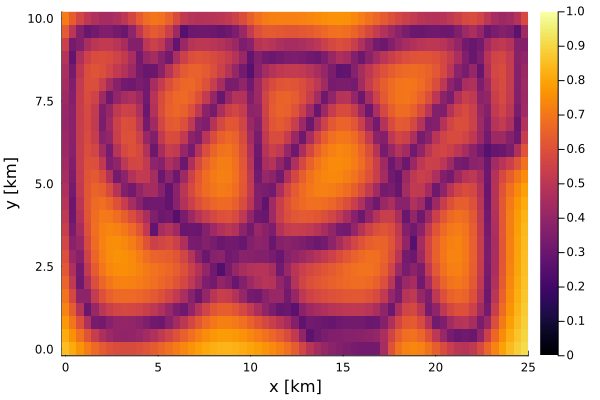

In [256]:
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end], clims=(0, 1.0), plotstd=true)
# for i=1:length(x0s)
#     x = [r[i][1] for r in res_ergo.xs]
#     y = [r[i][2] for r in res_ergo.xs]
#     plot!(x, y, linewidth=3)
# end
plot!()

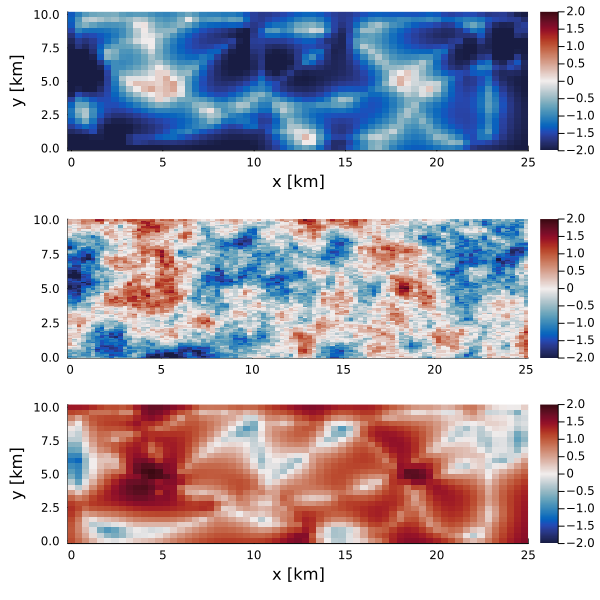

In [257]:
gr()

p1 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_min=true)
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_max=true)
p3 = heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
    
plot(p1, p3, p2, layout = (@layout [a;b; c]), size=[600, 600])

In [258]:
# Compute RMSE

Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)

# Estimate 
M = reshape(KF.μ(res_ergo.w_hats[end]), Nx, Ny)
heatmap(M',colormap=:balance, clims=(-2,2) )
x_new = 0:0.4:25
y_new = 0:0.4:10
Data_sampled = [env_data.itp_w(xi, yi) for yi in y_new, xi in x_new]
Diff = M' .- Data_sampled
rmse = sqrt(mean(Diff .^ 2))

0.38120928181387576

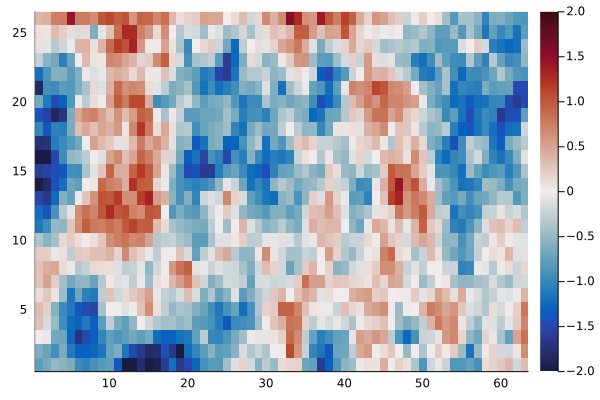

In [259]:
heatmap(Data_sampled,colormap=:balance, clims=(-2,2))

In [260]:
# Compute Precision

σ_prec = KF.σ(res_ergo.w_hats[end])
M_prec = reshape(σ_prec, Nx, Ny)
precision = sum(M_prec)/length(M_prec)

0.5161172120847358

In [261]:
using LinearAlgebra, StatsBase

mean_deficit_1 = [mean(map( c -> max(0, 1.0 - c), q )) for q in res_ergo.ergo_q_maps]
mean_deficit_1[end]

0.20937851230359755

In [262]:
ts = range(1, 100, 20)
time = collect(ts)

20-element Vector{Float64}:
   1.0
   6.2105263157894735
  11.421052631578947
  16.63157894736842
  21.842105263157894
  27.05263157894737
  32.26315789473684
  37.473684210526315
  42.68421052631579
  47.89473684210526
  53.10526315789474
  58.31578947368421
  63.526315789473685
  68.73684210526316
  73.94736842105263
  79.15789473684211
  84.36842105263158
  89.57894736842105
  94.78947368421052
 100.0

In [263]:
# plot(res_ergo.w_hat_ts, mean_deficit_1, marker=:dot)
gr()
plot()
plot!(time, mean_deficit_1, marker=:dot)
ylabel!("Clarity Deficit[0,1]")
xlabel!("Time [min]")
ylims!(0., 0.6)

attempt to save state beyond implementation limit
attempt to save state beyond implementation limit
